### Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

### Loading the data

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Dataset Shape

In [3]:
df.shape

(303, 14)

### Dataset Column Names

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Statistical Summary

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Droping Faulty Datas

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df = df[df['ca'] < 4] #drop the wrong ca values
df = df[df['thal'] > 0] # drop the wong thal value
print(f'The length of the data now is {len(df)} instead of 303!')

The length of the data now is 296 instead of 303!


In [10]:
print(df.shape)

(296, 14)


In [11]:
df.drop_duplicates(inplace=True) # REMOVING DUPLICATES

In [12]:
print(df.shape)

(296, 14)


### Heat Map

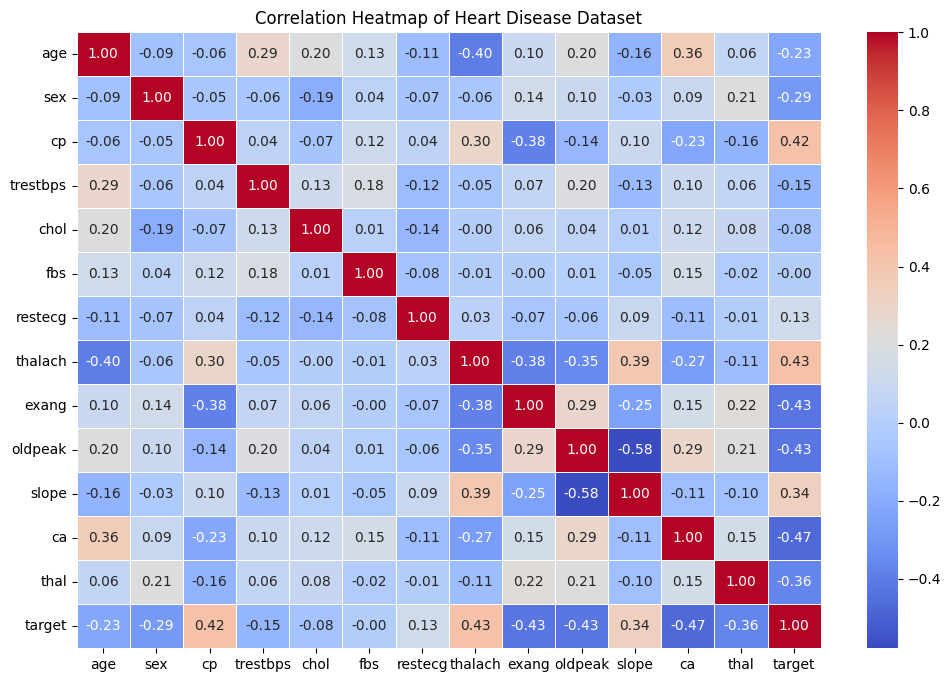

In [13]:
# Correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Heart Disease Dataset')
plt.show()

### Feature Selection

In [14]:
# Correlation with target
corr_target = df.corr()['target'].sort_values(ascending=False)

print(corr_target)

target      1.000000
thalach     0.426655
cp          0.423425
slope       0.337825
restecg     0.131716
fbs        -0.004680
chol       -0.076541
trestbps   -0.148922
age        -0.225453
sex        -0.285322
thal       -0.364399
exang      -0.425085
oldpeak    -0.428804
ca         -0.467158
Name: target, dtype: float64


In [15]:
#Select features with absolute correlation greater than 0.1
selected_features = corr_target[abs(corr_target) > 0.1].index     
print(selected_features)
df_selected = df[selected_features]

df_selected.head()

Index(['target', 'thalach', 'cp', 'slope', 'restecg', 'trestbps', 'age', 'sex',
       'thal', 'exang', 'oldpeak', 'ca'],
      dtype='str')


,target,thalach,cp,slope,restecg,trestbps,age,sex,thal,exang,oldpeak,ca
0,1,150,3,0,0,145,63,1,1,0,2.3,0
1,1,187,2,0,1,130,37,1,2,0,3.5,0
2,1,172,1,2,0,130,41,0,2,0,1.4,0
3,1,178,1,2,1,120,56,1,2,0,0.8,0
4,1,163,0,2,1,120,57,0,2,1,0.6,0


### PairPlot

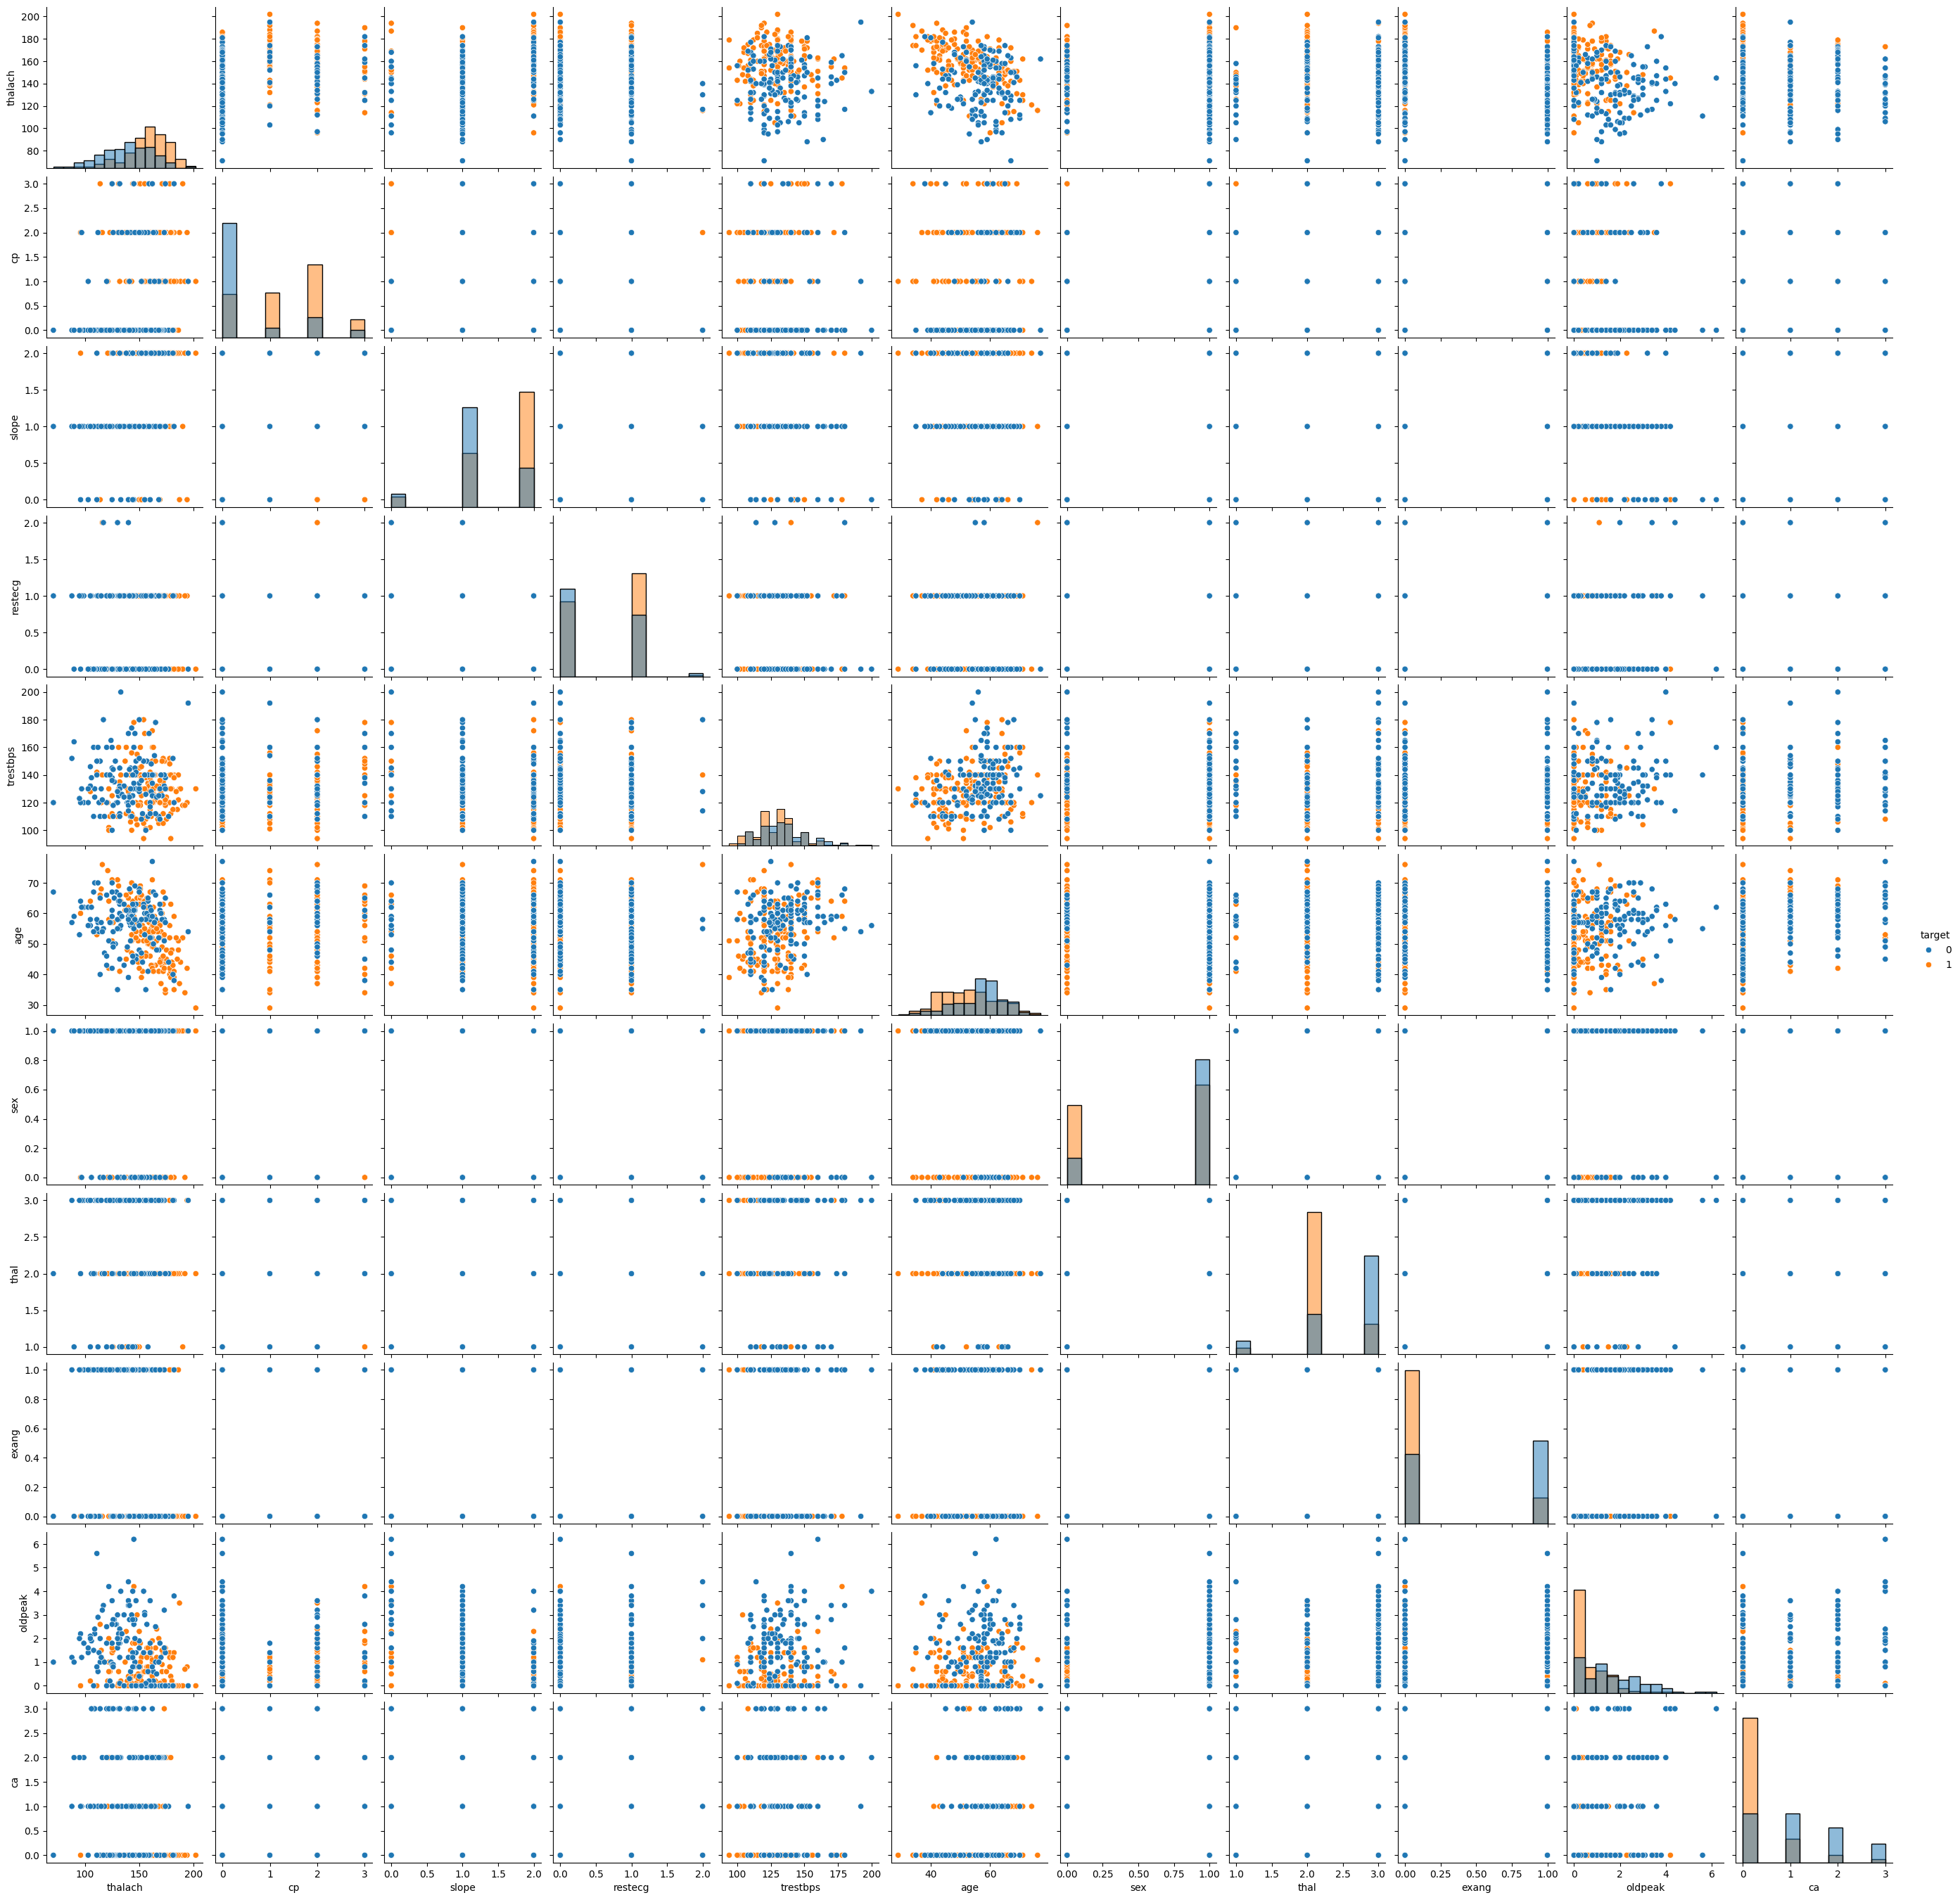

In [16]:

sns.pairplot(
    df_selected,
    hue='target',
    diag_kind='hist'
)

plt.show()

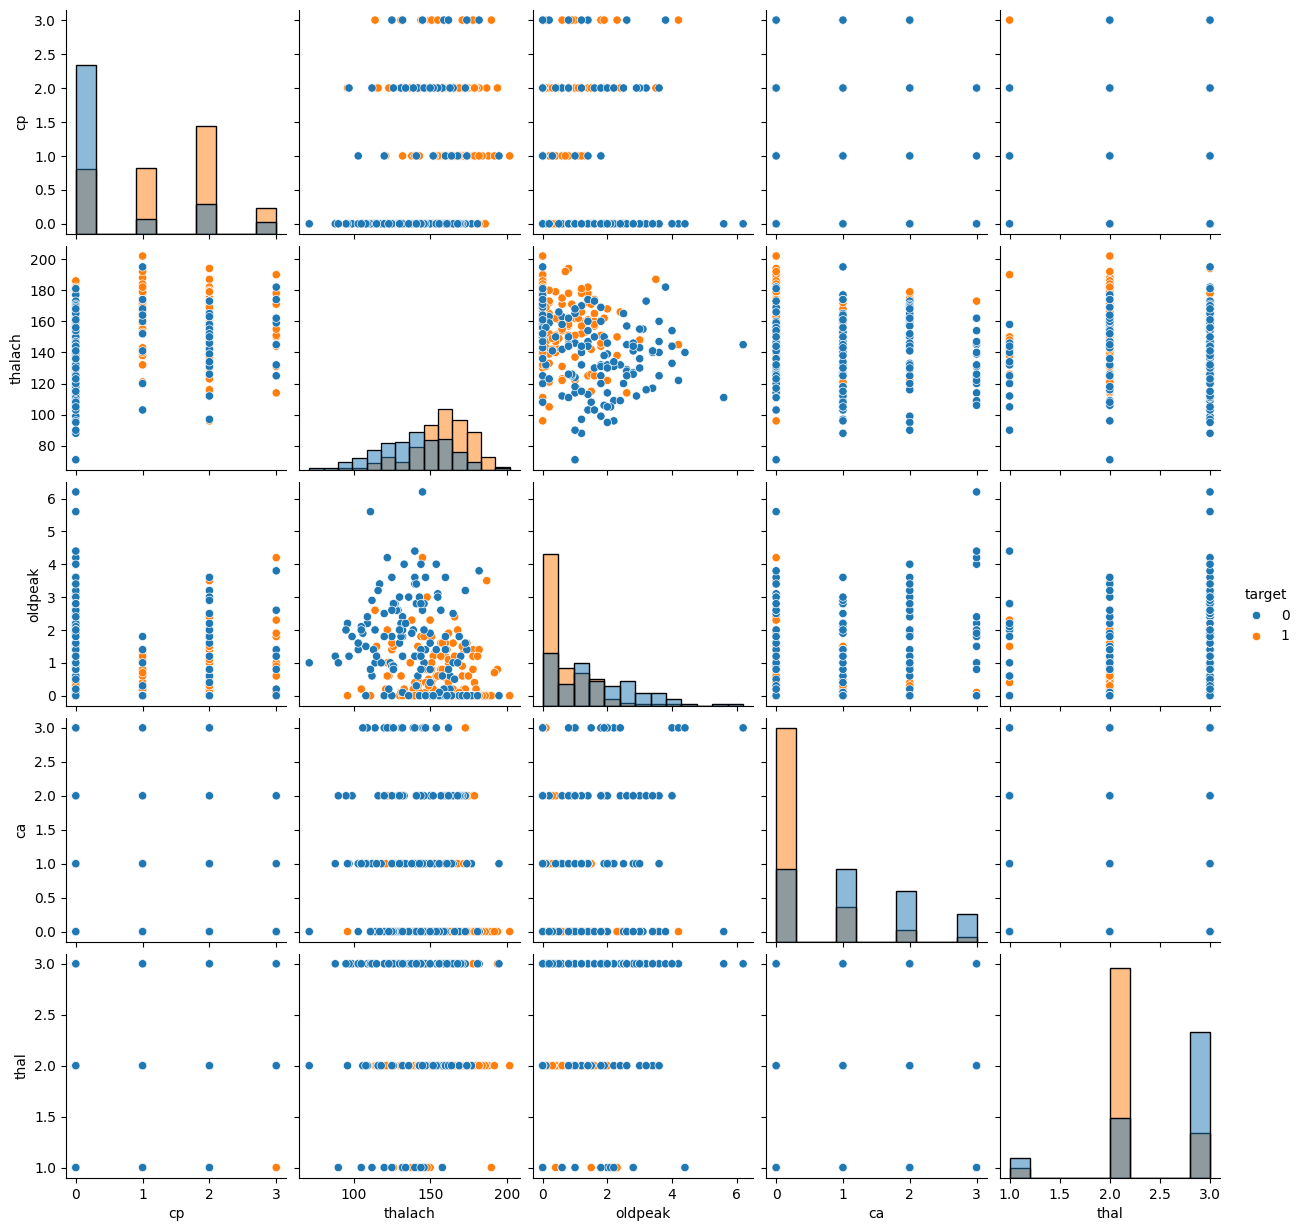

In [17]:
top_features = ['cp', 'thalach', 'oldpeak', 'ca', 'thal', 'target']

sns.pairplot(
    df[top_features],
    hue='target',
    diag_kind='hist'
)

plt.show()


### Scatter Plot

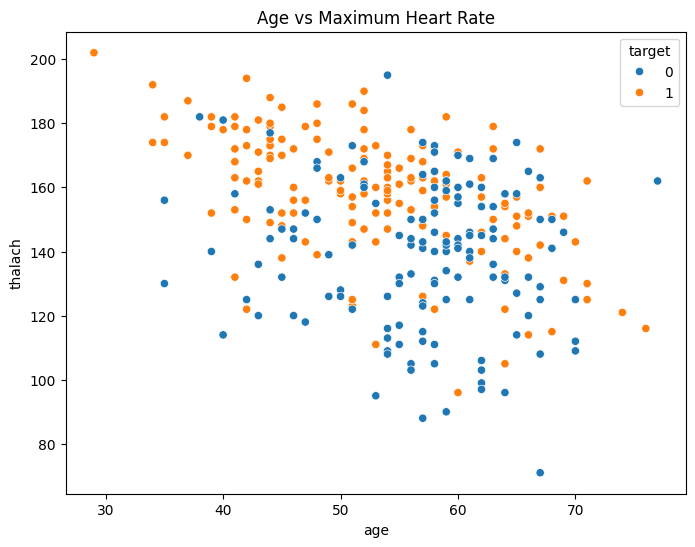

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='thalach',
    hue='target'
)

plt.title('Age vs Maximum Heart Rate')
plt.show()

### Hexbin Plot

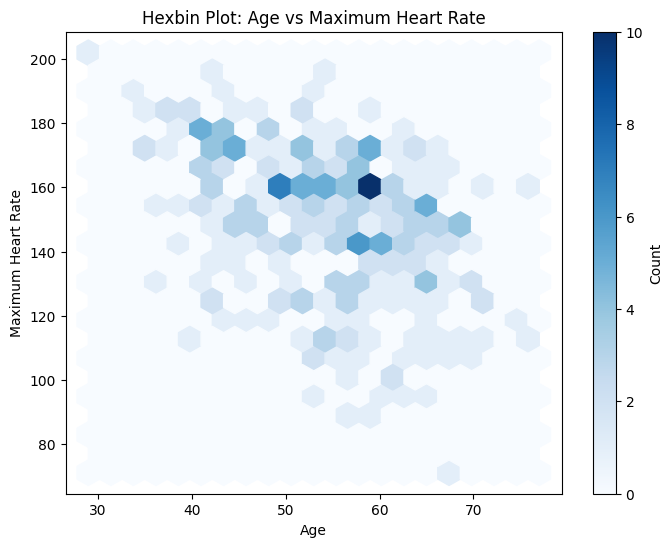

In [19]:
plt.figure(figsize=(8,6))

plt.hexbin(
    df['age'],
    df['thalach'],
    gridsize=20,
    cmap='Blues'
)

plt.colorbar(label='Count')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')
plt.title('Hexbin Plot: Age vs Maximum Heart Rate')

plt.show()

### Regression Plot

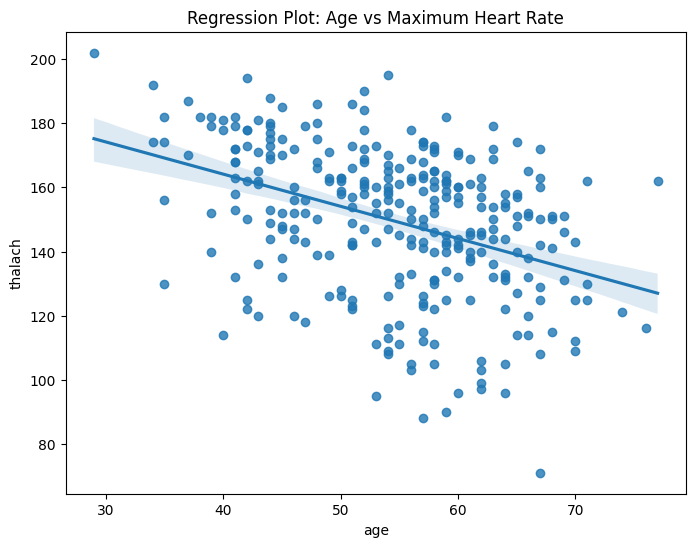

In [20]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='age',
    y='thalach',
    data=df
)

plt.title('Regression Plot: Age vs Maximum Heart Rate')

plt.show()

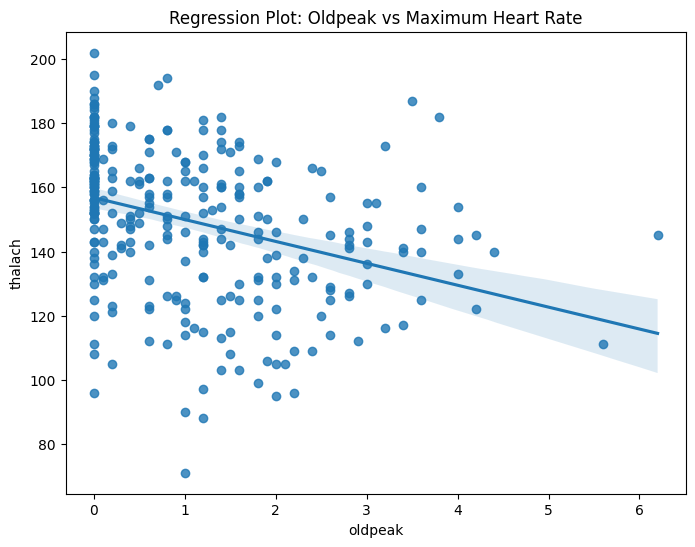

In [21]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='oldpeak',
    y='thalach',
    data=df
)

plt.title('Regression Plot: Oldpeak vs Maximum Heart Rate')

plt.show()

### Bar Plot with Mean Value

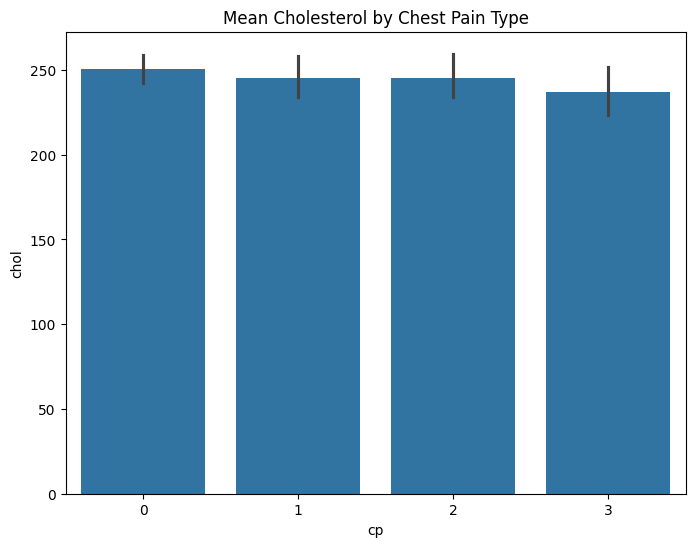

In [22]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='cp',
    y='chol',
    data=df,
    estimator='mean'
)

plt.title('Mean Cholesterol by Chest Pain Type')

plt.show()

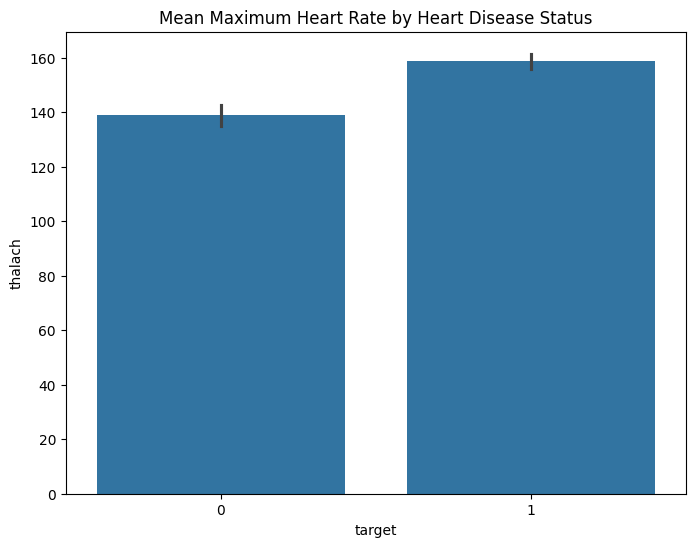

In [23]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='target',
    y='thalach',
    data=df,
    estimator='mean'
)

plt.title('Mean Maximum Heart Rate by Heart Disease Status')

plt.show()

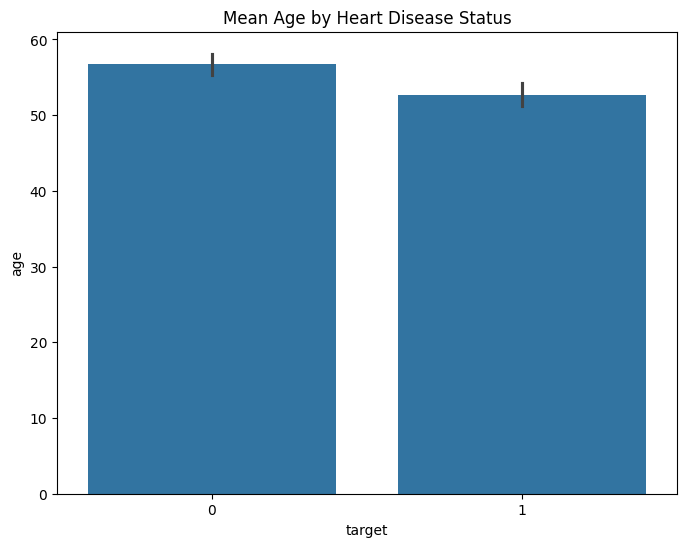

In [24]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='target',
    y='age',
    data=df,
    estimator='mean'
)

plt.title('Mean Age by Heart Disease Status')

plt.show()

### X,y Split

In [25]:
# Features and Target
X = df.drop('target', axis=1)
y = df['target']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (296, 13)
y Shape: (296,)


### One-Hot Encoding

In [26]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print(X.head())

   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak  ca   cp_1   cp_2  \
0   63    1       145   233    1      150      0      2.3   0  False  False   
1   37    1       130   250    0      187      0      3.5   0  False   True   
2   41    0       130   204    0      172      0      1.4   0   True  False   
3   56    1       120   236    0      178      0      0.8   0   True  False   
4   57    0       120   354    0      163      1      0.6   0  False  False   

    cp_3  restecg_1  restecg_2  slope_1  slope_2  thal_2  thal_3  
0   True      False      False    False    False   False   False  
1  False       True      False    False    False    True   False  
2  False      False      False    False     True    True   False  
3  False       True      False    False     True    True   False  
4  False       True      False    False     True    True   False  


### Tain Test split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(236, 18)
(60, 18)


### Standardizing the Data

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [29]:
# Train model
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr.predict(X_test_scaled)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8166666666666667

Confusion Matrix:
[[23  5]
 [ 6 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        28
           1       0.84      0.81      0.83        32

    accuracy                           0.82        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.82      0.82      0.82        60



### K - Nearest Neighbors

In [31]:
# Train model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8166666666666667

Confusion Matrix:
[[20  8]
 [ 3 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.78      0.91      0.84        32

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60



### Decision Tree

In [32]:
# Train model
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_scaled, y_train)

# Predictions
y_pred_dt = dt.predict(X_test_scaled)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7

Confusion Matrix:
[[21  7]
 [11 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.75      0.70        28
           1       0.75      0.66      0.70        32

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.71      0.70      0.70        60



### Random Forest

In [33]:
# Train model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf.predict(X_test_scaled)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7833333333333333

Confusion Matrix:
[[21  7]
 [ 6 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        28
           1       0.79      0.81      0.80        32

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



### Model Comparison

In [34]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results = results.sort_values(
    by='Accuracy',
    ascending=False
)

print(results)

                 Model  Accuracy
0  Logistic Regression  0.816667
1                  KNN  0.816667
3        Random Forest  0.783333
2        Decision Tree  0.700000


### Optimal Accuracy Bar Chart

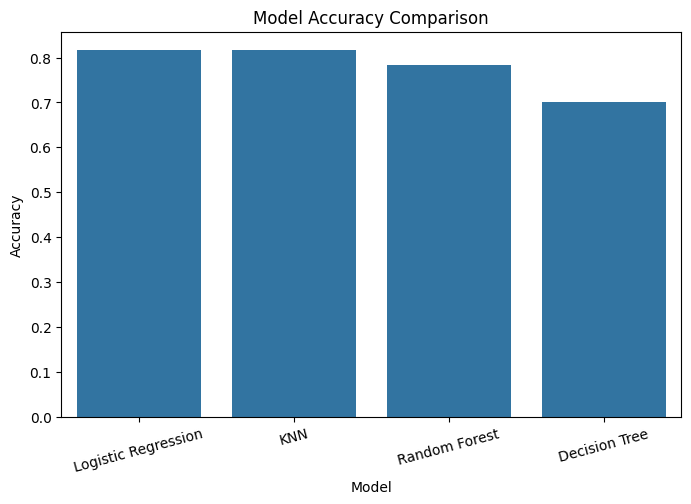

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.show()

### Saving the best model, features and pre processing datas.

In [36]:
import joblib

model_features = list(X.columns) # Capture feature names

heart_disease_artifacts = {
    'model': lr,        
    'scaler': scaler,   
    'features': model_features
}                                # Bundle artifacts

save_path = r"C:\Users\Maria Susan Ranji\Desktop\Nest\kaggle\HEART_DISEASE_RISK\best_heart_disease_model.pkl"  # Save to the absolute path 

joblib.dump(heart_disease_artifacts, save_path)

print(f"SUCCESSFULLY CREATED FILE AT:\n{save_path}")

SUCCESSFULLY CREATED FILE AT:
C:\Users\Maria Susan Ranji\Desktop\Nest\kaggle\HEART_DISEASE_RISK\best_heart_disease_model.pkl


In [37]:
import pandas as pd
import joblib

load_path = r"C:\Users\Maria Susan Ranji\Desktop\Nest\kaggle\HEART_DISEASE_RISK\best_heart_disease_model.pkl"  # Point to the exact same file path

loaded_artifacts = joblib.load(load_path)  # Load the file back into memory

loaded_model = loaded_artifacts['model']
loaded_scaler = loaded_artifacts['scaler']
loaded_features = loaded_artifacts['features']  # Extract the components

print("SUCCESS: Saved file successfully located and loaded back into Python!")
print(f"Model is ready and expects exactly {len(loaded_features)} features.\n")

new_patient_raw = df.drop('target', axis=1).iloc[[0]] 
new_patient_encoded = pd.get_dummies(new_patient_raw, columns=['cp', 'restecg', 'slope', 'thal'])
new_patient_ready = new_patient_encoded.reindex(columns=loaded_features, fill_value=0)
new_patient_scaled = loaded_scaler.transform(new_patient_ready)  # Test prediction on a new patient

prediction = loaded_model.predict(new_patient_scaled)
probability = loaded_model.predict_proba(new_patient_scaled)[:, 1]  # Output final classification and probability

print("--- Test Prediction Results ---")
print(f"Prediction Class: {prediction[0]} ({'Heart Disease Risk' if prediction[0] == 1 else 'Normal'})")
print(f"Calculated Risk Probability: {probability[0]:.2%}")

SUCCESS: Saved file successfully located and loaded back into Python!
Model is ready and expects exactly 18 features.

--- Test Prediction Results ---
Prediction Class: 1 (Heart Disease Risk)
Calculated Risk Probability: 86.80%
